# Risco em coberturas fixas

Visualização pós-hoc das previsões congeladas do holdout final local. Esta análise não retreina, recalibra nem seleciona limiares e não reabre o gate.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
artifact_dir = root / 'figures' / 'fixed_coverage_v1'
manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['scope'] == 'posthoc_reporting_from_frozen_predictions'
assert manifest['gate_remained_locked'] is True
risk = pd.read_csv(artifact_dir / 'fixed_coverage_risk.csv')
risk.head()

,method,method_label,coverage,risk,ci_lower,ci_upper,accepted_mass,boundary_score,boundary_tie_count,boundary_fraction
0,bm25,BM25 top-1,0.1,0.645161,0.516129,0.838710,31.0,190.047489,1,1.000000
1,logistic,Logística,0.1,0.322581,0.161290,0.516129,31.0,0.783928,1,1.000000
2,rrf,RRF top-1,0.1,0.452830,0.361687,0.546407,31.0,0.032787,106,0.292453
3,semantic,Semântico top-1,0.1,0.516129,0.322581,0.677419,31.0,0.926499,1,1.000000
4,bm25,BM25 top-1,0.2,0.661290,0.548387,0.790323,62.0,146.482759,1,1.000000


In [2]:
table = risk.pivot(index='method_label', columns='coverage', values='risk')
table.style.format('{:.1%}').set_caption('Risco seletivo por cobertura fixada')

coverage,0.100000,0.200000,0.400000,0.600000,0.800000,1.000000
method_label,,,,,,
BM25 top-1,64.5%,66.1%,66.1%,64.0%,65.7%,66.1%
Logística,32.3%,35.5%,45.2%,53.8%,60.1%,66.1%
RRF top-1,45.3%,45.3%,47.9%,53.3%,59.7%,66.1%
Semântico top-1,51.6%,50.0%,56.5%,60.8%,62.5%,66.1%


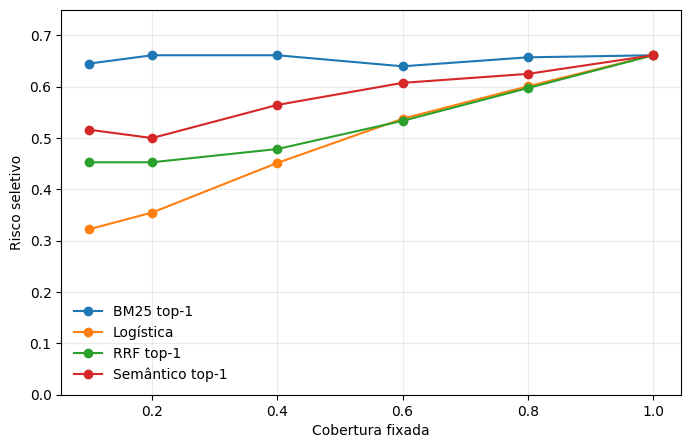

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for method, rows in risk.groupby('method_label'):
    rows = rows.sort_values('coverage')
    ax.plot(rows['coverage'], rows['risk'], marker='o', label=method)
ax.set(xlabel='Cobertura fixada', ylabel='Risco seletivo', ylim=(0, 0.75))
ax.grid(alpha=.25)
ax.legend(frameon=False)
plt.show()

A logística apresenta menor risco observado que o RRF em 10%, 20% e 40% de cobertura, mas os intervalos pareados da redução incluem zero. Em 60% e 80%, o RRF é ligeiramente melhor. Em 100%, todos aceitam as mesmas perguntas.